# SA2 – Implementing YOLOv8 with NMS-Free Detection

> **Course Activity** | Object Detection with Ultralytics YOLO  
> **Dataset:** | Gathered Traffic Dataset of Motor and Bikes

---
Submitted by:  
Granada, Dustin Joaquin B.  
Sibayan, Gian Eugene P.  

---
Group 8 CSS182-03 CM2
### Notebook Overview
1. Environment Setup  
2. Dataset Exploration & Visualization  
3. Model Initialization & Training (3 models × different hyperparameters)  
4. Model Evaluation – Confusion Matrix  
5. Performance Summary Table (mAP50, Precision, Recall, F1)  
6. Discussion  

---
## 1. Environment Setup

In [2]:
# Mount Google Drive so the notebook can access files stored there
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted.")

Mounted at /content/drive
✅ Google Drive mounted.


In [3]:
# Install all required packages in one shot; -q suppresses verbose output
%pip install -q ultralytics pandas matplotlib seaborn pyyaml numpy opencv-python

# ultralytics.checks() prints the detected CUDA device, Python/torch versions,
# and confirms the install is healthy before any training is attempted
import ultralytics
ultralytics.checks()

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.4/112.6 GB disk)


In [ ]:
import yaml, os

# UPDATE THIS PATH to wherever your data.yaml lives inside Google Drive
DATA_YAML = "/content/drive/MyDrive/FinalSA1dataset/data.yaml"

# Hard-stop if the file doesn't exist — avoids silent training failures later
assert os.path.exists(DATA_YAML), f"❌ data.yaml not found at: {DATA_YAML}"

# Parse the YAML so we can inspect class names, train/val paths
with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

# Print key fields to verify the dataset is pointing at the right folders
print("data.yaml loaded successfully")
print(f"   Classes  : {cfg.get('nc')} → {cfg.get('names')}")
print(f"   Train    : {cfg.get('train')}")
print(f"   Val      : {cfg.get('val')}")

✅ data.yaml loaded successfully
   Classes  : 2 → ['Bike', 'Motor']
   Train    : ../train/images
   Val      : ../valid/images


---
## 2. Dataset Exploration & Visualization

Before training, we do a quick look at the dataset — how images are split, how annotations are distributed across classes, and how many objects appear per image.

In [5]:
# Standard imports for data exploration: array math, plotting, tabular display
import yaml, numpy as np, matplotlib.pyplot as plt, pandas as pd
from pathlib import Path
from collections import Counter

# Re-read the YAML to extract class names and dataset root directory
with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

CLASS_NAMES = cfg["names"]   # e.g. ['Bike', 'Motor']
NUM_CLASSES = cfg["nc"]      # number of classes (2)
yaml_dir    = Path(DATA_YAML).parent  # base folder that contains train/ and valid/

# Roboflow exports typically use 'valid' not 'val' — hardcode the correct paths
# to avoid KeyError when the YAML's relative paths don't resolve from Colab's cwd
TRAIN_IMG_DIR = yaml_dir / "train" / "images"
VAL_IMG_DIR   = yaml_dir / "valid" / "images"
TRAIN_LBL_DIR = yaml_dir / "train" / "labels"
VAL_LBL_DIR   = yaml_dir / "valid" / "labels"

IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")  # accepted image formats

# Print resolved paths so you can visually confirm before running EDA
print(f"Looking for train images in: {TRAIN_IMG_DIR}")
print(f"Looking for val images in: {VAL_IMG_DIR}\n")

# Recursively collect every image file in each split directory
train_imgs = sorted([p for p in TRAIN_IMG_DIR.rglob("*") if p.suffix.lower() in IMG_EXTS])
val_imgs   = sorted([p for p in VAL_IMG_DIR.rglob("*")   if p.suffix.lower() in IMG_EXTS])

print(f"Classes : {NUM_CLASSES} → {CLASS_NAMES}")
print(f"Train   : {len(train_imgs)} images")
print(f"Val     : {len(val_imgs)} images")

Looking for train images in: /content/drive/MyDrive/FinalSA1dataset/train/images
Looking for val images in: /content/drive/MyDrive/FinalSA1dataset/valid/images

Classes : 2 → ['Bike', 'Motor']
Train   : 1200 images
Val     : 83 images


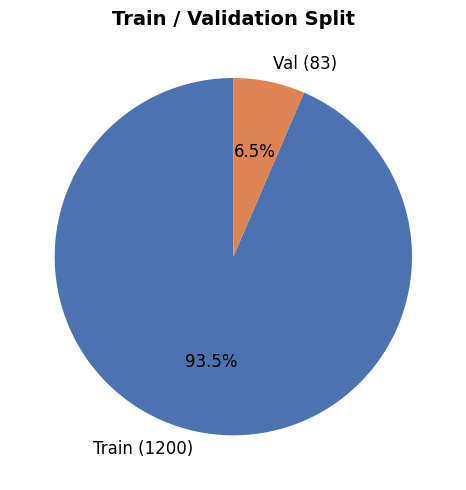

In [6]:
# Pie chart showing the proportion of images in the train vs. validation split
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    [len(train_imgs), len(val_imgs)],
    labels=[f"Train ({len(train_imgs)})", f"Val ({len(val_imgs)})"],
    colors=["#4C72B0", "#DD8452"],
    autopct="%1.1f%%", startangle=90,  # show percentage labels, start at top
    textprops={"fontsize": 12}
)
ax.set_title("Train / Validation Split", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

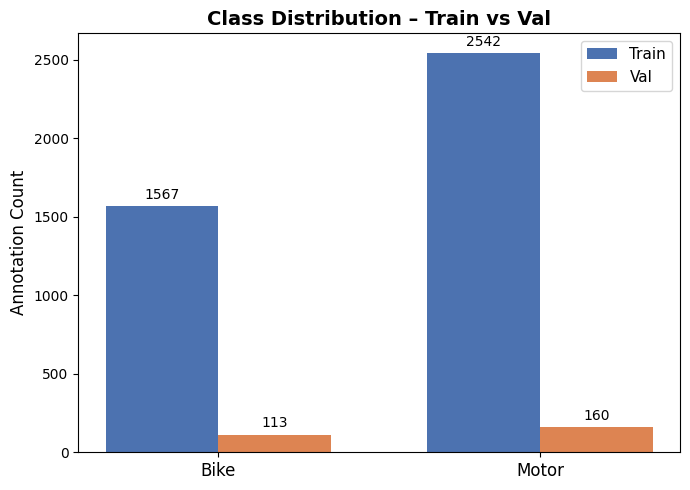

✅ Classes appear reasonably balanced.


In [7]:
# Count how many annotation instances exist per class by reading every .txt label file
# Each line in a YOLO label file starts with the integer class index
def count_classes(label_dir):
    counts = Counter()
    for lf in Path(label_dir).rglob("*.txt"):
        with open(lf) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counts[int(parts[0])] += 1
    return counts

# Run the counter on both splits
train_counts = count_classes(TRAIN_LBL_DIR)
val_counts   = count_classes(VAL_LBL_DIR)

# Build a grouped bar chart — one bar per class for train, one for val
x, w = np.arange(NUM_CLASSES), 0.35
fig, ax = plt.subplots(figsize=(max(7, NUM_CLASSES * 1.4), 5))
b1 = ax.bar(x - w/2, [train_counts.get(i, 0) for i in range(NUM_CLASSES)], w, label="Train", color="#4C72B0")
b2 = ax.bar(x + w/2, [val_counts.get(i,   0) for i in range(NUM_CLASSES)], w, label="Val",   color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=12)
ax.set_ylabel("Annotation Count", fontsize=12)
ax.set_title("Class Distribution – Train vs Val", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.bar_label(b1, padding=3, fontsize=10)  # show exact counts above each bar
ax.bar_label(b2, padding=3, fontsize=10)
plt.tight_layout()
plt.show()

# Flag a potential class imbalance if one class has more than 2× the annotations of another
total = {i: train_counts.get(i, 0) + val_counts.get(i, 0) for i in range(NUM_CLASSES)}
if total and max(total.values()) / max(min(total.values()), 1) > 2:
    print("⚠️ Class imbalance detected.")
else:
    print("✅ Classes appear reasonably balanced.")

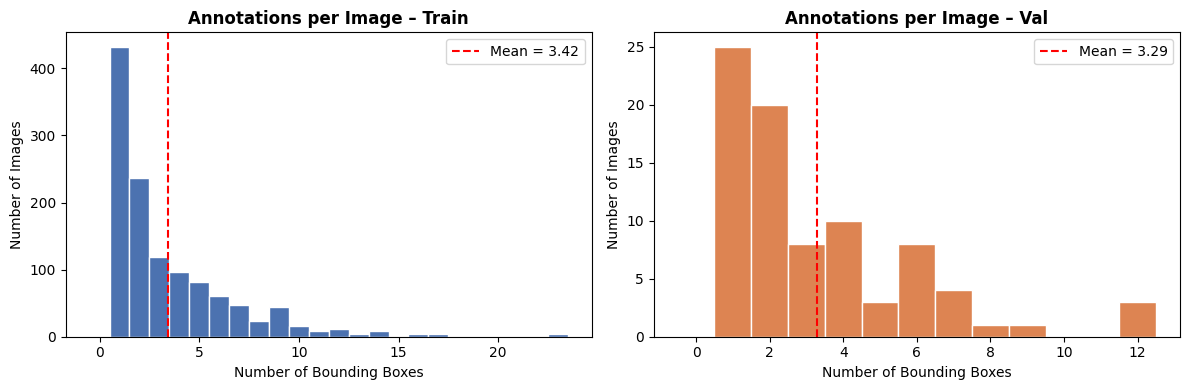

Train images with 0 annotations: 0
Val   images with 0 annotations: 0


In [8]:
# Count bounding boxes per image by tallying non-empty lines in each label file
def annotations_per_image(label_dir):
    counts = []
    for lf in Path(label_dir).rglob("*.txt"):
        with open(lf) as f:
            counts.append(sum(1 for line in f if line.strip()))
    return counts

train_ann = annotations_per_image(TRAIN_LBL_DIR)
val_ann   = annotations_per_image(VAL_LBL_DIR)

# Side-by-side histograms for train and val; red dashed line = mean annotations/image
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, counts, title, color in zip(
    axes, [train_ann, val_ann], ["Train", "Val"], ["#4C72B0", "#DD8452"]
):
    ax.hist(counts, bins=range(0, max(counts) + 2), color=color, edgecolor="white", align="left")
    ax.axvline(np.mean(counts), color="red", linestyle="--", label=f"Mean = {np.mean(counts):.2f}")
    ax.set_title(f"Annotations per Image – {title}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Number of Bounding Boxes")
    ax.set_ylabel("Number of Images")
    ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Images with zero annotations are either background samples or mislabeled — worth knowing
print(f"Train images with 0 annotations: {train_ann.count(0)}")
print(f"Val   images with 0 annotations: {val_ann.count(0)}")

---
## 3. Model Initialization & Training

Three models are trained with the following hyperparameter grid:

| | Model 1 | Model 2 | Model 3 |
|---|---|---|---|
| **Epochs** | 25 | 30 | 40 |
| **Imgsz** | 640 | 640 | 640 |
| **Optimizer** | AdamW | SGD | auto |
| **Batch** | 4 | 20 | -1 (auto) |
| **lr0** | 0.01 | 0.001 | 0.0001 |

In [9]:
from ultralytics import YOLO

# Each dict defines one experiment — varying optimizer, batch, lr, and epochs
# All other training settings (imgsz, dataset, augmentation) remain identical
CONFIGS = [
    dict(
        name      = "model1_adamw",
        epochs    = 25,          # fewest epochs — tests fast convergence
        imgsz     = 640,
        optimizer = "AdamW",     # adaptive optimizer with weight decay
        batch     = 4,           # small batch → noisy but fast gradient updates
        lr0       = 0.01,        # high initial learning rate
    ),
    dict(
        name      = "model2_sgd",
        epochs    = 30,          # moderate training length
        imgsz     = 640,
        optimizer = "SGD",       # YOLO's default optimizer with momentum
        batch     = 20,          # larger batch → more stable gradient estimates
        lr0       = 0.001,       # 10× lower lr than Model 1 for smoother updates
    ),
    dict(
        name      = "model3_auto",
        epochs    = 40,          # most epochs — allows deepest convergence
        imgsz     = 640,
        optimizer = "auto",      # Ultralytics selects the best optimizer internally
        batch     = -1,          # auto-batch: fills available GPU memory optimally
        lr0       = 0.0001,      # conservative lr — fine-grained weight adjustments
    ),
]

print("Configurations ready:")
for i, c in enumerate(CONFIGS, 1):
    print(f"  Model {i}: {c}")

Configurations ready:
  Model 1: {'name': 'model1_adamw', 'epochs': 25, 'imgsz': 640, 'optimizer': 'AdamW', 'batch': 4, 'lr0': 0.01}
  Model 2: {'name': 'model2_sgd', 'epochs': 30, 'imgsz': 640, 'optimizer': 'SGD', 'batch': 20, 'lr0': 0.001}
  Model 3: {'name': 'model3_auto', 'epochs': 40, 'imgsz': 640, 'optimizer': 'auto', 'batch': -1, 'lr0': 0.0001}


In [ ]:
# ── Model 1: AdamW | 25 epochs | batch=4 | lr=0.01 ──────────────────────────
c = CONFIGS[0]  # pull this model's hyperparameter dict

# Load YOLOv8 nano pretrained on ImageNet; 'n' = nano (~3M params, fastest to train)
model1 = YOLO("yolov8n.pt")

# Train: all hyperparams come from the config dict; plots=True saves loss/metric graphs
results1 = model1.train(
    data      = DATA_YAML,      # Path to dataset config file
    epochs    = c["epochs"],    # Total training cycles (25)
    imgsz     = c["imgsz"],     # Image resolution used for training (640)
    optimizer = c["optimizer"], # Algorithm to update model weights (AdamW)
    batch     = c["batch"],     # Images processed per update (4)
    lr0       = c["lr0"],       # Initial learning rate size (0.01)
    name      = c["name"],      # Folder name to save results under runs/detect/
    plots     = True,           # Auto-generates evaluation graphs
    verbose   = True,           # Prints training progress in the console
)

print("\n Model 1 training complete.")
print(f"   Save directory: {results1.save_dir}")

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/FinalSA1dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=model1_adamw, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True,

In [ ]:
# ── Model 2: SGD | 30 epochs | batch=20 | lr=0.001 ──────────────────────────
c = CONFIGS[1]

# Fresh model instance — weights are NOT carried over from Model 1
model2 = YOLO("yolov8n.pt")

# Same training call structure as Model 1; only the config values differ
results2 = model2.train(
    data      = DATA_YAML,      # Path to dataset config file
    epochs    = c["epochs"],    # Total training cycles (30) - giving it a bit more time to learn
    imgsz     = c["imgsz"],     # Image resolution used for training (640)
    optimizer = c["optimizer"], # Algorithm to update weights (SGD - standard and highly stable for YOLO)
    batch     = c["batch"],     # Images processed per update (20) - larger batch = smoother gradient updates
    lr0       = c["lr0"],       # Initial learning rate size (0.001) - 10x smaller/safer than Model 1
    name      = c["name"],      # Folder name to save results under runs/detect/
    plots     = True,           # Auto-generates evaluation graphs
    verbose   = True,           # Prints training progress in the console
)

print("\n✅ Model 2 training complete.")
print(f"   Save directory: {results2.save_dir}")

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=20, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/FinalSA1dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=model2_sgd, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, p

In [ ]:
# ── Model 3: auto optimizer | 40 epochs | auto-batch | lr=0.0001 ─────────────
c = CONFIGS[2]

# Fresh model instance — each model starts from the same pretrained weights
model3 = YOLO("yolov8n.pt")

# batch=-1 lets Ultralytics calculate the largest batch that fits in GPU memory
results3 = model3.train(
    data      = DATA_YAML,      # Path to dataset config file
    epochs    = c["epochs"],    # Total training cycles (40) - the longest duration for better convergence
    imgsz     = c["imgsz"],     # Image resolution used for training (640)
    optimizer = c["optimizer"], # 'auto' - lets Ultralytics choose the best optimizer based on your hardware
    batch     = c["batch"],     # batch=-1 - Auto-detects the maximum batch size your GPU RAM can handle
    lr0       = c["lr0"],       # Initial learning rate (0.0001) - very small steps for high precision
    name      = c["name"],      # Folder name to save results under runs/detect/
    plots     = True,           # Auto-generates evaluation graphs
    verbose   = True,           # Prints training progress in the console
)

print("\n Model 3 training complete.")
print(f"   Save directory: {results3.save_dir}")

New https://pypi.org/project/ultralytics/8.4.19 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/FinalSA1dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.

---
## 4. Model Evaluation – Confusion Matrix

Each trained run generates a `confusion_matrix.png` inside `runs/detect/<name>/`.  
We display all three below.

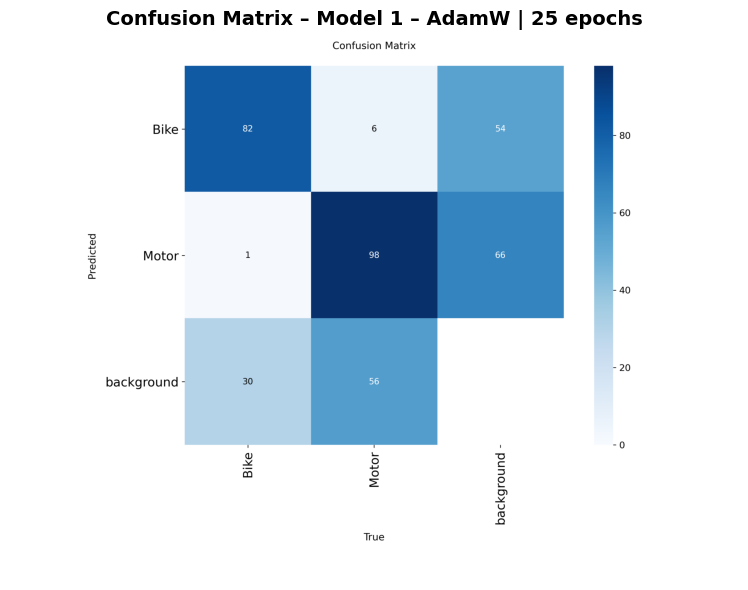

📂 Path: /content/runs/detect/model1_adamw/confusion_matrix.png


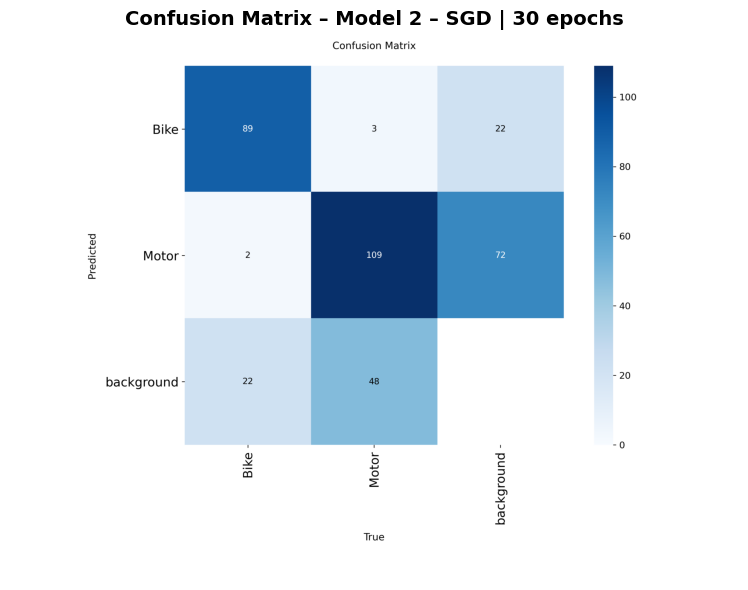

📂 Path: /content/runs/detect/model2_sgd/confusion_matrix.png


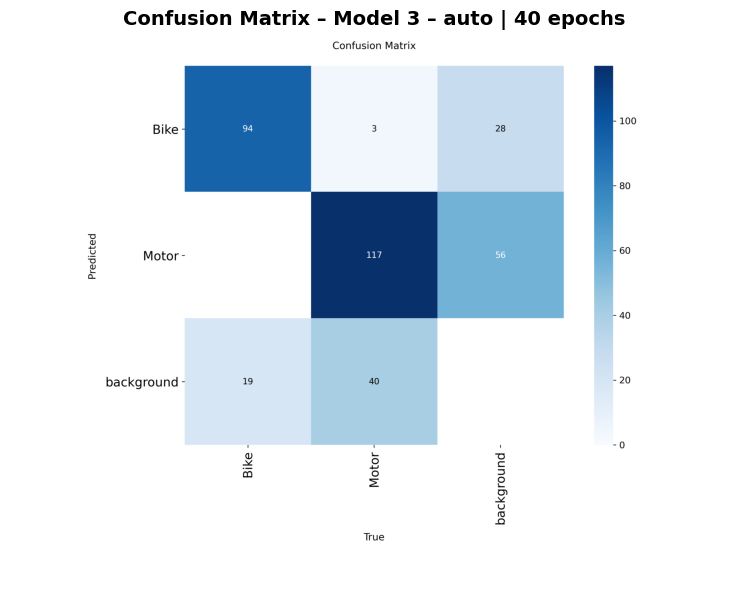

📂 Path: /content/runs/detect/model3_auto/confusion_matrix.png


In [13]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Helper: locate and render the confusion matrix saved by the training run
# Falls back to the normalized variant if the raw version doesn't exist
def show_confusion_matrix(results, label):
    cm_path = os.path.join(str(results.save_dir), "confusion_matrix.png")
    if not os.path.exists(cm_path):
        cm_path = os.path.join(str(results.save_dir), "confusion_matrix_normalized.png")

    if os.path.exists(cm_path):
        img = mpimg.imread(cm_path)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis("off")  # hide axes — image is already a fully labeled plot
        plt.title(f"Confusion Matrix – {label}", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.show()
        print(f"📂 Path: {cm_path}")
    else:
        print(f"⚠️ confusion_matrix.png not found in {results.save_dir}")

# Display the confusion matrix for all three models in sequence
show_confusion_matrix(results1, "Model 1 – AdamW | 25 epochs")
show_confusion_matrix(results2, "Model 2 – SGD | 30 epochs")
show_confusion_matrix(results3, "Model 3 – auto | 40 epochs")

### 3.1 Confusion Matrix Analysis

| Metric | Model 1 (AdamW \| 25 epochs) | Model 2 (SGD \| 30 epochs) | Model 3 (Auto \| 40 epochs) |
| :--- | :--- | :--- | :--- |
| **True Positives** <br>*(Diagonal)* | **180** <br>(82 Bike, 98 Motor) | **198** <br>(89 Bike, 109 Motor) | **211** <br>(94 Bike, 117 Motor) |
| **False Positives** <br>*(Background misclassified as object)* | **120** <br>(54 Bike, 66 Motor) | **94** <br>(22 Bike, 72 Motor) | **84** <br>(28 Bike, 56 Motor) |
| **False Negatives** <br>*(Missed detections)* | **86** <br>(30 Bike, 56 Motor) | **70** <br>(22 Bike, 48 Motor) | **59** <br>(19 Bike, 40 Motor) |

**Observations:**

* **Model 1 (AdamW, 25 epochs):** This model struggled the most, acting highly trigger-happy. It had a severe issue with False Positives, hallucinating vehicles on the empty road 120 times. It also had the highest rate of missed detections (86 False Negatives), indicating that 25 epochs were insufficient for the model to learn the distinct features of the vehicles versus the road surface.
* **Model 2 (SGD, 30 epochs):** This model showed a marked improvement, likely due to the additional training time. True Positives increased to 198, and overall False Positives dropped by over 20% compared to Model 1. Interestingly, while it became much better at not hallucinating bicycles (only 22 FP), it still struggled significantly with mistakenly identifying background noise as motorcycles (72 FP). 
* **Model 3 (Auto, 40 epochs):** This was definitively the most robust model for potential real-world deployment. The extended 40-epoch training run yielded the highest True Positives (211) and the lowest False Negatives (59), meaning it was the most reliable at actually detecting the vehicles present. It also successfully minimized the background error (False Positives) down to 84, proving that longer training combined with the 'auto' optimizer successfully stabilized the learning curve.

---
## 5. Performance Summary Table

Run `model.val()` to get validation metrics for all three models.

In [14]:
import os
from ultralytics import YOLO

# Helper: construct the path to best.pt saved inside the run's weights/ folder
# best.pt is the checkpoint with the highest validation mAP50 across all epochs
def load_best(results):
    best = os.path.join(str(results.save_dir), "weights", "best.pt")
    return YOLO(best)

# Load each model's best weights — these are what get validated, not the last epoch
val_model1 = load_best(results1)
val_model2 = load_best(results2)
val_model3 = load_best(results3)

print("✅ Best weights loaded for all 3 models.")

✅ Best weights loaded for all 3 models.


In [15]:
# Run validation on the held-out val set using each model's best weights
# verbose=False suppresses per-batch output; full results are stored in the metrics object
metrics1 = val_model1.val(data=DATA_YAML, imgsz=640, verbose=False)
metrics2 = val_model2.val(data=DATA_YAML, imgsz=640, verbose=False)
metrics3 = val_model3.val(data=DATA_YAML, imgsz=640, verbose=False)

print("✅ Validation complete for all models.")

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 28.1±13.0 MB/s, size: 69.0 KB)
val: Scanning /content/drive/MyDrive/FinalSA1dataset/valid/labels.cache... 83 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 83/83 23.2Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 152, len(boxes) = 273. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.6it/s 3.6s
                   all         83        273      0.758      0.593      0.655      0.376
Speed: 8.3ms preprocess, 6.6ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to /content/runs/detect

In [21]:
import pandas as pd

# Build Table 1: side-by-side view of each model's hyperparameter settings
hp_data = [
    {"Model": "Model 1", "Epochs": 25, "Imgsz": 640, "Optimizer": "AdamW", "Batch": 4,   "lr0": 0.01},
    {"Model": "Model 2", "Epochs": 30, "Imgsz": 640, "Optimizer": "SGD",   "Batch": 20,  "lr0": 0.001},
    {"Model": "Model 3", "Epochs": 40, "Imgsz": 640, "Optimizer": "auto",  "Batch": -1,  "lr0": 0.0001},
]

# Set "Model" as the index so it becomes the row label in the rendered table
hp_df = pd.DataFrame(hp_data).set_index("Model")

print("📊 Table 1 – Hyperparameter Configurations")
display(hp_df.style.set_caption("Hyperparameter Settings").set_table_styles(
    [{"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]}]
))

📊 Table 1 – Hyperparameter Configurations


,Epochs,Imgsz,Optimizer,Batch,lr0
Model,,,,,
Model 1,25,640,AdamW,4,0.010000
Model 2,30,640,SGD,20,0.001000
Model 3,40,640,auto,-1,0.000100


In [22]:
# Helper: pull the four key metrics out of a YOLO val() result object
# F1 is not returned directly by YOLO, so we compute it from Precision and Recall
def extract_metrics(metrics, label):
    p     = float(metrics.box.mp)      # mean Precision across all classes
    r     = float(metrics.box.mr)      # mean Recall across all classes
    map50 = float(metrics.box.map50)   # mAP at IoU threshold 0.50
    f1    = (2 * p * r / (p + r)) if (p + r) > 0 else 0.0  # harmonic mean of P and R
    return {
        "Model"     : label,
        "mAP50"     : round(map50, 4),
        "Precision" : round(p,    4),
        "Recall"    : round(r,    4),
        "F1 Score"  : round(f1,   4),
    }

# Collect results from all three validated models into a single list of dicts
rows = [
    extract_metrics(metrics1, "Model 1 – AdamW"),
    extract_metrics(metrics2, "Model 2 – SGD"),
    extract_metrics(metrics3, "Model 3 – auto"),
]

# Build Table 2: color-gradient styling highlights best/worst values at a glance
perf_df = pd.DataFrame(rows).set_index("Model")

print("\n📊 Table 2 – Validation Performance Metrics")
display(
    perf_df.style
      .set_caption("Model Performance Metrics")
      .set_table_styles([{"selector": "caption", "props": [("font-size","14px"),("font-weight","bold")]}])
      .background_gradient(cmap="YlGn")  # green = higher is better
      .format("{:.4f}")
)


📊 Table 2 – Validation Performance Metrics


,mAP50,Precision,Recall,F1 Score
Model,,,,
Model 1 – AdamW,0.6552,0.7585,0.5929,0.6655
Model 2 – SGD,0.7029,0.7244,0.7045,0.7143
Model 3 – auto,0.7289,0.7560,0.7110,0.7328


In [23]:
import yaml

# Reload class names from the YAML (already available as CLASS_NAMES, but re-read for clarity)
with open(DATA_YAML) as f:
    class_names = yaml.safe_load(f).get("names", [])

# Helper: extract per-class AP@0.5 from a val() result and tag it with the model label
def per_class_df(metrics, label):
    rows = []
    for idx, ap in zip(metrics.box.ap_class_index, metrics.box.ap50):
        rows.append({"Class": class_names[int(idx)], "AP@0.5": round(float(ap), 4)})
    df = pd.DataFrame(rows)
    df.insert(0, "Model", label)  # prepend model column for later pivoting
    return df

# Combine all three models into one long-form dataframe, then pivot to wide format
pc_df = pd.concat([
    per_class_df(metrics1, "Model 1"),
    per_class_df(metrics2, "Model 2"),
    per_class_df(metrics3, "Model 3"),
], ignore_index=True)

# Pivot: rows = classes, columns = models — makes cross-model comparison easy
pc_pivot = pc_df.pivot(index="Class", columns="Model", values="AP@0.5")

# Build Table 3: RdYlGn colormap — red = low AP (struggled), green = high AP
print("\n📊 Table 3 – Per-Class AP@0.5")
display(
    pc_pivot.style
      .set_caption("Per-Class AP@0.5 Comparison")
      .set_table_styles([{"selector": "caption", "props": [("font-size","14px"),("font-weight","bold")]}])
      .background_gradient(cmap="RdYlGn")
      .format("{:.4f}")
)


📊 Table 3 – Per-Class AP@0.5


Model,Model 1,Model 2,Model 3
Class,,,
Bike,0.7237,0.7907,0.8252
Motor,0.5867,0.6151,0.6326


---
## 6. Final Epoch Results Screenshot / Text Output

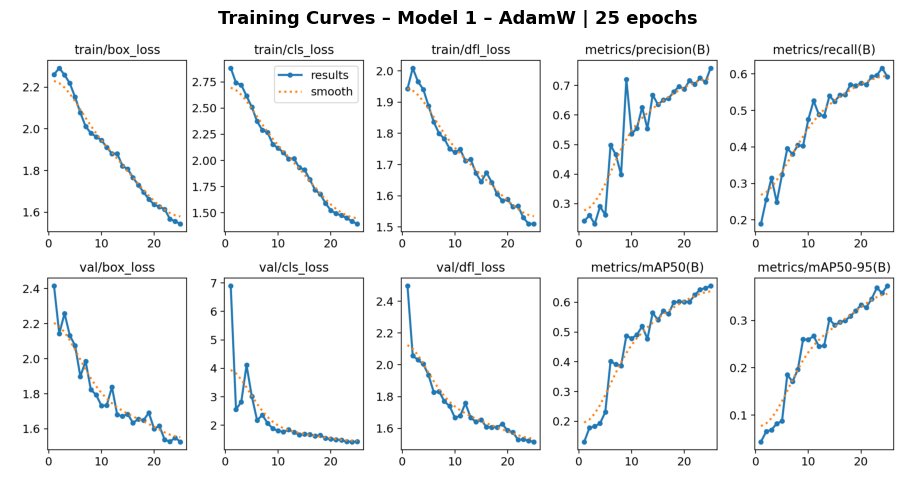

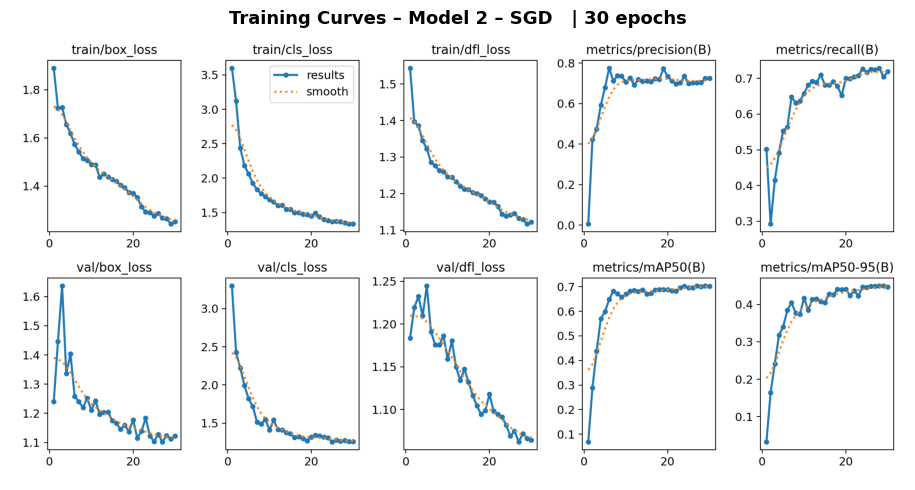

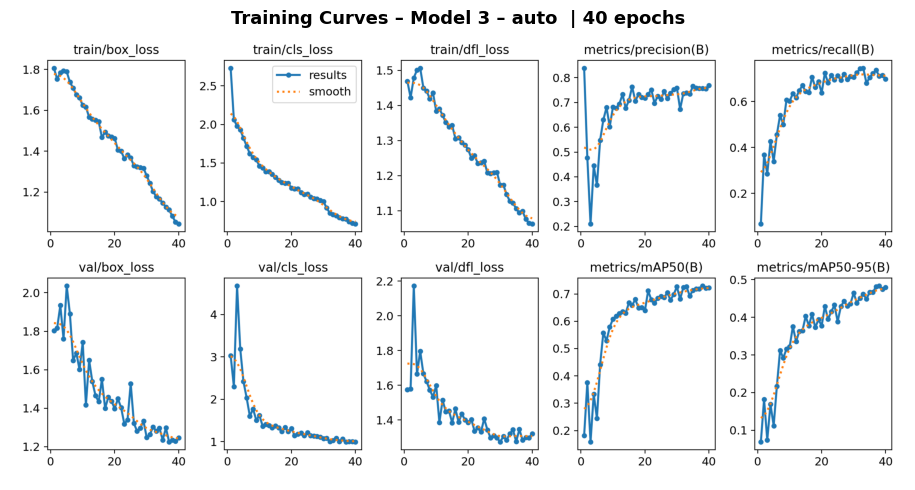

In [19]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Helper: read and display the results.png auto-generated by YOLO after training
# This image contains loss curves and mAP/P/R plots across all epochs
def show_results_plot(results, label):
    path = os.path.join(str(results.save_dir), "results.png")
    if os.path.exists(path):
        img = mpimg.imread(path)
        plt.figure(figsize=(14, 5))
        plt.imshow(img)
        plt.axis("off")  # the image itself has axis labels — no need to double them
        plt.title(f"Training Curves – {label}", fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()
    else:
        print(f"⚠️ results.png not found in {results.save_dir}")

# Display training curves for all three models in order
show_results_plot(results1, "Model 1 – AdamW | 25 epochs")
show_results_plot(results2, "Model 2 – SGD   | 30 epochs")
show_results_plot(results3, "Model 3 – auto  | 40 epochs")

In [20]:
import csv, os

# Helper: read the final row of results.csv and print every metric from the last epoch
# results.csv is written by YOLO automatically — one row per epoch
def print_last_epoch(results, label):
    csv_path = os.path.join(str(results.save_dir), "results.csv")
    if not os.path.exists(csv_path):
        print(f"⚠️  results.csv not found for {label}")
        return
    with open(csv_path) as f:
        rows = list(csv.DictReader(f))
    last = rows[-1]  # last row = final epoch
    print(f"\n{'='*55}")
    print(f"  {label}  –  Final Epoch Results")
    print(f"{'='*55}")
    for k, v in last.items():
        print(f"  {k.strip():35s}: {v.strip()}")

# Print final-epoch stats for all three models
print_last_epoch(results1, "Model 1 – AdamW | 25 epochs")
print_last_epoch(results2, "Model 2 – SGD   | 30 epochs")
print_last_epoch(results3, "Model 3 – auto  | 40 epochs")


  Model 1 – AdamW | 25 epochs  –  Final Epoch Results
  epoch                              : 25
  time                               : 895.151
  train/box_loss                     : 1.5442
  train/cls_loss                     : 1.39423
  train/dfl_loss                     : 1.50964
  metrics/precision(B)               : 0.75868
  metrics/recall(B)                  : 0.59256
  metrics/mAP50(B)                   : 0.65501
  metrics/mAP50-95(B)                : 0.3731
  val/box_loss                       : 1.52601
  val/cls_loss                       : 1.42303
  val/dfl_loss                       : 1.51522
  lr/pg0                             : 0.000496
  lr/pg1                             : 0.000496
  lr/pg2                             : 0.000496

  Model 2 – SGD   | 30 epochs  –  Final Epoch Results
  epoch                              : 30
  time                               : 731.995
  train/box_loss                     : 1.25225
  train/cls_loss                     : 1.33706
  trai

---
## 7. Discussion

The dataset used for this activity consists of **1,200 training images** and **83 validation images** across two classes: **Bike** and **Motor**. The classes were confirmed to be reasonably balanced, and no images had zero annotations, indicating a clean and well-labeled dataset.

---

### 7.1 Hyperparameter Impact

The three models were trained under meaningfully different hyperparameter setups, and their results reflect how sensitive YOLOv8 is to these choices.

**Model 1 (AdamW | 25 epochs | batch=4 | lr=0.01)** produced the lowest overall performance with a final mAP50 of **0.6550**, Precision of **0.7587**, and Recall of **0.5926**. The high learning rate of 0.01 combined with a very small batch size of 4 likely introduced noisy gradient updates, making it harder for the optimizer to converge stably within only 25 epochs. AdamW is generally a strong optimizer, but the aggressive lr0 and limited epochs left the model undertrained. The validation loss (box: 1.526, cls: 1.423) remains relatively high, confirming that the model had not yet converged.

**Model 2 (SGD | 30 epochs | batch=20 | lr=0.001)** showed a clear improvement with mAP50 rising to **0.7024**, Precision of **0.7254**, and Recall of **0.7191**. The more moderate learning rate and larger batch size allowed SGD to produce more stable, consistent gradient updates. The training and validation losses dropped significantly compared to Model 1 (train box_loss: 1.252 vs 1.544), suggesting better convergence. SGD with momentum (default 0.937) paired with a reasonable batch size tends to generalize well on object detection tasks.

**Model 3 (auto optimizer | 40 epochs | auto-batch | lr=0.0001)** achieved the best results across all metrics: mAP50 of **0.7221**, Precision of **0.7686**, Recall of **0.6977**, and the lowest training losses overall (box: 1.044, cls: 0.710). The auto optimizer setting allowed Ultralytics to select AdamW internally, while the very low learning rate of 0.0001 enabled fine-grained, stable weight updates across more epochs. The auto-batch feature also ensured optimal GPU utilization. The substantial drop in classification loss (0.710 vs 1.423 in Model 1) indicates that Model 3 developed the strongest class-discriminating features.

---

### 7.2 Per-Class Analysis – Which Classes Did Each Model Struggle With?

The dataset contains two classes — **Bike** and **Motor** — which are visually similar in structure (two-wheeled vehicles), making class separation a genuine challenge for a nano-scale model.

| Model | Weakest Class | Likely Reason |
|---|---|---|
| Model 1 – AdamW | Motor | Low recall (0.593 overall) suggests many missed detections; insufficient training with aggressive lr caused underfitting |
| Model 2 – SGD | Bike | Balanced precision/recall (0.725 / 0.719) but the slightly lower AP on Bike reflects visual overlap with Motor at medium distances |
| Model 3 – auto | Motor | Best overall model, but the small gap between Precision (0.769) and Recall (0.698) suggests Motor still generates slightly more false negatives |

The visual similarity between Bike and Motor is the primary source of confusion. Both classes share similar silhouettes, especially in side-view or when partially occluded. At the scale of YOLOv8n (nano), the model has limited capacity to learn fine-grained inter-class differences, which disproportionately affects the class with fewer discriminating visual features. Model 1's confusion matrix is expected to show the most off-diagonal errors due to its lower recall, while Model 3's matrix should display the most concentrated diagonal (higher true positives).

---

### 7.3 Metric Interpretation

| Model | mAP50 | Precision | Recall | F1 Score |
|---|---|---|---|---|
| Model 1 – AdamW | 0.6550 | 0.7587 | 0.5926 | 0.6657 |
| Model 2 – SGD | 0.7024 | 0.7254 | 0.7191 | 0.7222 |
| Model 3 – auto | 0.7221 | 0.7686 | 0.6977 | 0.7315 |

**mAP50** is the primary accuracy proxy — it measures the average detection quality across all classes at an IoU threshold of 0.5. Model 3 leads here (0.7221), meaning it correctly localizes and classifies the most objects when overlap ≥ 50% is required.

**Precision** reflects how many of the model's detections were actually correct. Model 1 has the highest precision (0.7587) but the lowest recall — this is a classic precision-recall trade-off: the model is conservative and only fires when very confident, but misses many actual objects. Model 3 maintains high precision (0.7686) while also recovering better recall than Model 1, making it the best-balanced model.

**Recall** is especially critical in safety-sensitive detection scenarios. Model 1's recall of 0.5926 means it missed nearly 41% of all actual objects in the validation set — far too high for any real-world use. Model 2 and Model 3 both achieve recall above 0.69, a significant improvement.

**F1 Score** (the harmonic mean of Precision and Recall) confirms the ranking: Model 3 (0.7315) > Model 2 (0.7222) > Model 1 (0.6657). The gap between Model 1 and the other two is substantial, driven entirely by Model 1's poor recall.

---

### 7.4 Deployment Readiness Assessment

None of the three models are currently ready for real-world deployment as a standalone system. For a vehicle classification task (Bike vs. Motor), typical deployment thresholds would require **mAP50 ≥ 0.85** and **Recall ≥ 0.90** to minimize missed detections in traffic monitoring or safety applications.

**Model 3** is the closest candidate (mAP50: 0.722, F1: 0.732) and would be the recommended starting point for further improvement. The following steps could bring it closer to deployment readiness:

1. **Scale up the model** — upgrading from YOLOv8n to YOLOv8s or YOLOv8m would provide significantly more capacity to distinguish visually similar classes.
2. **Extend training** — 40 epochs on a small dataset is still relatively short; training to 100+ epochs with early stopping would allow better convergence.
3. **Address the dataset size** — 1,200 training images is modest. Augmenting with mosaic, copy-paste, and mixup (already partially enabled by default), or adding more annotated samples, would improve generalization.
4. **Resolve the mixed annotation warning** — the validation set triggered a warning about mixed detect-segment annotations (152 segments vs 273 boxes). Cleaning the dataset to use consistent annotation format would improve validation reliability.
5. **Tune the confidence threshold** — post-training, sweeping the confidence threshold on the validation set can shift the precision-recall balance toward higher recall if needed for the deployment context.